# **Семинар 2. Взаимодействие с API и проектирование своего API, немного сетей.**

## **Задача 1. REST API. Пайплайн STRING-UniProt-AlphaFoldDB**

Пусть мы хотим понять, насколько изучен белковый интерактом какого-то белка человека. Для этого, для исследуемого белка нам хочется найти его подтверждённых белковых партнёров и понять, насколько качественные у них структуры. Откуда же всё это брать?

1. Белковых партнёров возьмём из БД STRING: [STRING-db](https://string-db.org/).
2. Оценку качества структуры возьмём как средний pLDDT из AlphaFoldDB: [AlphaFoldDB](https://alphafold.ebi.ac.uk/)
3. STRING работает на всех генных символах, а AlphaFoldDB, как часть ensembl и InterPro, поэтому нам придётся вытащить из InterPro правильный ID белка. Оттуда же можно вытащить GO-термины, которыми мы так же можем проаннотировать интерактом. InterPro: [InterPro API](https://www.ebi.ac.uk/interpro/api/)

In [ ]:
import time
import requests
import pandas as pd

### STRING.
Сначала давайте разберёмся с эндпоинтами в STRING.

Вот эндпоинт, который нам нужен:
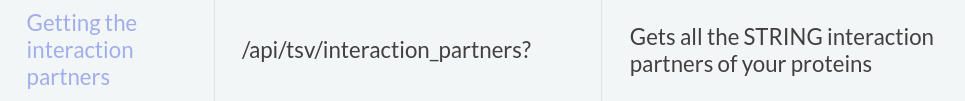


А также документация запроса:

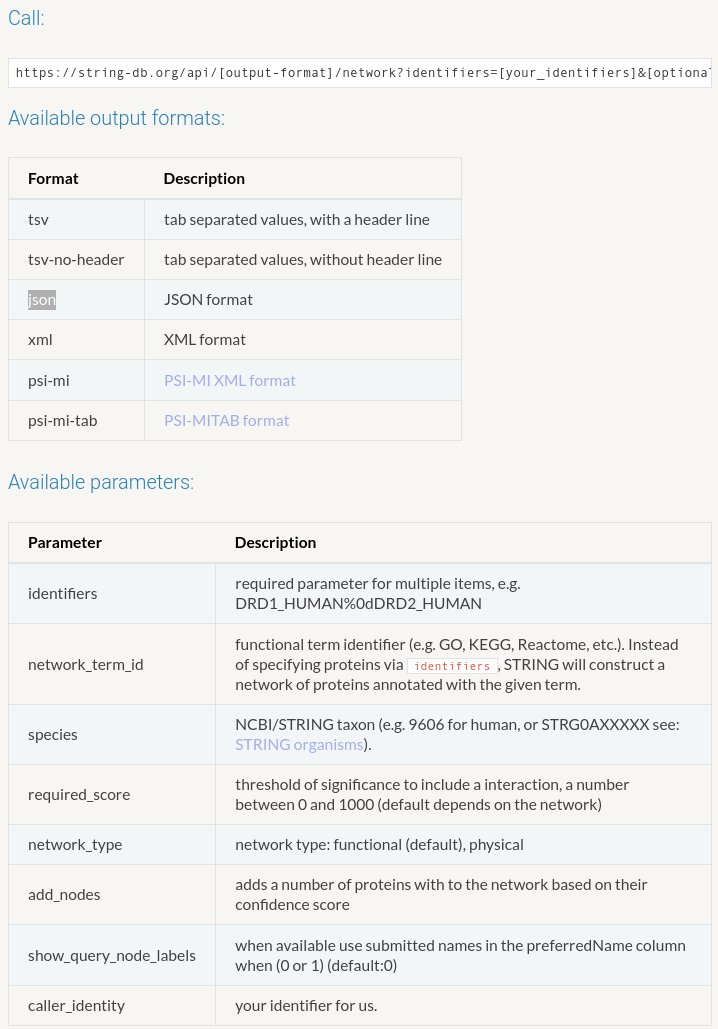

Теперь соберём запрос к STRING. Единственное, что нам надо дополнительно знать $-$ идентификатор человека как вида в STRING. Самый простой способ узнать это $-$ вкладка [Downloads](https://string-db.org/cgi/download) на веб-сервисе. Но можно и в NCBI Taxonomy залезть.

Напишите функцию `get_string_partners`, принимающую на вход символ гена и количество партнёров, которых надо вернуть, а также ID вида.

In [ ]:
STRING_API = "https://string-db.org/api"

def get_string_partners(gene, n=10, sp_id=9606):
  r = requests.get(f"{STRING_API}/json/interaction_partners",
                    params={"identifiers": gene, "species": sp_id,
                            "limit": n})
  r.raise_for_status()
  return [
    {"name": p["preferredName_B"], "score": p["score"]}
    for p in r.json()[:n] #gets returned sorted
  ]

Тестируем:

In [ ]:
get_string_partners("EZH2", n=2, sp_id=9606)

[{'name': 'SUZ12', 'score': 0.999}, {'name': 'RBBP7', 'score': 0.999}]

In [ ]:
get_string_partners("Ezh2", n=2, sp_id=10090)

[{'name': 'Yy1', 'score': 0.999}, {'name': 'Rbbp7', 'score': 0.999}]

### InterPro / UniProt
Теперь обратимся к API InterPro. Сразу подскажу путь эндпоинтов, по которому нам надо пройти. Так как мы, по сути, ищем только метаданные о белке, нам потребуется `/api/protein`. Кроме того, давайте брать данные из UniProt, поэтому нам нужен именно `/api/protein/uniprot`.

Получить правильный символ гена мы можем сразу из ответа на наш запрос, это будет поле `name`. Однако GO-терм придётся запросить у API дополнительно. Это можно сделать, добавив в запрос поле `extra_fields`. Все значения этого поля документированы в официальном референсе [API InterPRO](https://github.com/ProteinsWebTeam/interpro7-api/blob/master/docs/modifiers.md#apiprotein-uniprotreviewedunreviewed-).

Более того, получить значения поля можно проще, выбив их непосредственно из API:

In [ ]:
r = requests.get(
    "https://www.ebi.ac.uk/interpro/api/protein/reviewed/",
    params={"search": "TP53", "page_size": 1, "extra_fields": "INVALID"}
)
print(r.status_code, r.json()['Error'], sep='\n')

404
INVALID is not a valid field to to be included. Allowed fields : accession, identifier, organism, name, description, sequence_bin, length, proteome, gene, go_terms, evidence_code, source_database, structure, is_fragment, in_alphafold, in_bfvd, tax_id, ida_id, ida, counts, counters, sequence


Осталось только понять, какие нам нужны параметры payload самого запроса. Это уже упомянутый выше `search`, `page_size` для пагинации. Еще нам понадобится `tax_id` как идентификатор таксона.

Напишите функцию `fetch_from_interpro`, принимающую символ гена и (опционально) ID организма и возвращающую UniProt Accession ID, длину белка и список GO-терминов по Molecular Function.

In [ ]:
def fetch_from_interpro(gene, sp_id=9606):
  r = requests.get(
      "https://www.ebi.ac.uk/interpro/api/protein/reviewed/",
      params={"search": gene, "tax_id": sp_id,
              "page_size": 1, "extra_fields": "go_terms"}
      )
  r.raise_for_status()
  if not r.text:
    return None
  results = r.json().get("results", [])
  if not results:
    return None
  meta = results[0]["metadata"]
  acc = meta["accession"]
  length = meta.get("length", 0)
  terms_to_check = results[0].get("extra_fields", {}).get("go_terms") or []
  go_terms = []
  for term in terms_to_check:
    if term.get("category", {}).get("code") == "F":
      go_terms.append(term["name"])

  return {"accession": acc, "length": length, "go_mf": go_terms}

Тестируем:

In [ ]:
fetch_from_interpro("EZH2")

{'accession': 'Q15910',
 'length': 746,
 'go_mf': ['histone H3K27 methyltransferase activity',
  'protein binding',
  'histone methyltransferase activity']}

In [ ]:
fetch_from_interpro("Ezh2", sp_id=10090)

{'accession': 'Q61188',
 'length': 746,
 'go_mf': ['histone H3K27 methyltransferase activity',
  'protein binding',
  'histone methyltransferase activity']}

Почему не `uniprot`, а `reviewed`? Эндпоинт `uniprot` работает с гораздо большей БД и потому запросы к нему отправляются сервером в бэкграунд, а на первый раз отправляется ошибка 408. Можно повторить запрос через несколько секунд, согласно советам [API InterPro](https://interpro-documentation.readthedocs.io/en/latest/faq.html#why-do-i-get-http-timeouts-code-408-when-running-queries). Альтернативой будет посыл запросов к старому API UniProt.

In [ ]:
def fetch_from_uniprot(gene, sp_id=9606):
  r = requests.get(
      "https://rest.uniprot.org/uniprotkb/search",
      params={"query": f"gene_exact:{gene} AND organism_id:{sp_id} AND reviewed:true",
              "fields": "accession,length,go_f",
              "format": "json", "size": 1}
      )
  r.raise_for_status()
  results = r.json().get("results", [])
  if not results:
    return None
  entry = results[0]
  acc = entry["primaryAccession"]
  length = entry.get("sequence", {}).get("length", 0)
  go_terms = []
  for ref in entry.get("uniProtKBCrossReferences", []):
    if ref.get("database") == "GO":
      props = {p["key"]: p["value"] for p in ref.get("properties", [])}
      if props.get("GoTerm", "").startswith("F:"):
        go_terms.append(props["GoTerm"][2:])

  return {"accession": acc, "length": length, "go_mf": go_terms}

### AlphaFoldDB

Тут никаких секретов нет, просто обращаемся к API базы данных по эндпоинту `prediction` в public-API. Напишите функцию `get_alphafold_pLDDT`, принимающую UniProt Accession ID и возвращающую значение метрики pLDDT для заданного белка согласно предсказанию AlphaFold.

In [ ]:
def get_alphafold_pLDDT(accession):
    r = requests.get(f"https://alphafold.ebi.ac.uk/api/prediction/{accession}")
    r.raise_for_status()

    data = r.json()
    if isinstance(data, list):
        data = data[0]
    return data.get("globalMetricValue", None)

Тестируем:

In [ ]:
get_alphafold_pLDDT('Q15910')

76.25

Объединяем всё вместе:

In [ ]:
def run_calling(gene):
    partners = get_string_partners(gene)
    rows = []
    for p in partners:
        name = p["name"]
        time.sleep(1)
        info = fetch_from_uniprot(name) # plug
        if info is None:
            rows.append({
                "partner": name, "uniprot_id": None,
                "length": None, "mean_pLDDT": None,
                "top_GO_MF": None, "string_score": p["score"]
            })
            continue

        plddt = get_alphafold_pLDDT(info["accession"])
        top_go = info["go_mf"][0] if info["go_mf"] else None
        rows.append({
            "partner": name, "uniprot_id": info["accession"],
            "length": info["length"], "mean_pLDDT": plddt,
            "top_GO_MF": top_go, "string_score": p["score"]
        })
    df = pd.DataFrame(rows)
    return df

In [ ]:
run_calling('EZH2')

,partner,uniprot_id,length,mean_pLDDT,top_GO_MF,string_score
0,SUZ12,Q15022,739,71.00,chromatin DNA binding,0.999
1,RBBP7,Q16576,425,90.75,histone binding,0.999
2,RBBP4,Q09028,425,91.69,histone binding,0.999
3,EED,O75530,441,86.50,chromatin binding,0.999
4,DNMT1,P26358,1616,77.81,DNA (cytosine-5-)-methyltransferase activity,0.999
5,HDAC1,Q13547,482,86.25,core promoter sequence-specific DNA binding,0.999
6,BMI1,P35226,326,76.75,promoter-specific chromatin binding,0.999
7,DNMT3B,Q9UBC3,853,72.56,DNA (cytosine-5-)-methyltransferase activity,0.999
8,HDAC2,Q92769,488,85.56,chromatin binding,0.999
9,AEBP2,Q6ZN18,517,61.84,DNA binding,0.999


## **Задача 2. Requests-кроулер + FastAPI: микросервис аннотации последовательностей**

Напишем FastAPI-приложение, в котором будет 2 эндпоинта.
- `GET /orthologs/{gene_symbol}` — принимает символ гена, делает цепочку запросов `requests`:
  1. На `/xrefs/symbol/homo_sapiens/{symbol}` получает ENSGID для человека.
  2. По ENSGID запрашивает `/homology/id/human/{ENSGID}?type=orthologues&target_taxon=10090` (мышь), в ответе получая ортологичный ген в мыши.
  3. Для ортолога запрашивает `/lookup/id/{mouse_id}?expand=1`, достаёт координаты, биотип, display_name.
  4. Возвращает клиенту JSON с информацией по человеческому и мышиному генам.

- `POST /batch_orthologs` — принимает JSON-список символов генов (до 20 штук), делает то же самое для каждого (неасинхронно).

Сделаем с `Pydantic`-моделями. Сервер должен корректно обрабатывать случаи: символ не найден, ортолог отсутствует.

Опять же, сначала посмотрим на то, как выглядит документация API ensembl: [Ensembl-API reference](https://rest.ensembl.org/).

Нас интересуют эндпоинты кросс-референса `/xrefs/` (то, как одни ID маппируются на другие, [**Документация**](https://rest.ensembl.org/documentation/info/xref_external)), гомологии `/homology/` (как ID генов в одном организме маппируются на гены в другому организме согласно их гомологичному происхождению, [**Документация**](https://rest.ensembl.org/documentation/info/homology_species_gene_id)), поиска `/lookup/` ([**Документация**](https://rest.ensembl.org/documentation/info/lookup)).

In [ ]:
import time
import requests
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

Напишем несколько вспомогательных функций для внутреннего API. Ensembl как популярный ресурс обладает жесткими границами по частоте обращения к их сервисам, поэтому требуется отдельно обрабатывать `429 Too many requests`.

In [ ]:
def ensembl_get(path, params=None):
  url = requests.compat.urljoin("https://rest.ensembl.org/", path)
  r = requests.get(url,
                   headers={"Content-Type": "application/json"},
                   params=params or {}, timeout=15)
  if r.status_code == 429:
    wait = int(r.headers.get("Retry-After", 1))
    time.sleep(wait)
    return ensembl_get(path, params)
  if r.status_code != 200:
    print(f"[ensembl_get] {r.status_code} for {r.url}")
    print(f"[ensembl_get] {r.text[:300]}")
    return None
  return r.json()

Напишем функции для последовательного обращения к API ensembl. Сначала $-$ `get_ensgid`, которая принимает символ гена и возвращает ENSG ID. Опять же, для того, чтобы распарсить пришедший в ответе JSON, требуется на него посмотреть, и понять, что вам нужно.

In [ ]:
def get_ensgid(symbol):
  xrefs = ensembl_get(f"/xrefs/symbol/homo_sapiens/{symbol}")
  if not xrefs:
    return None, f"Symbol {symbol} not found in ensembl"
  gene_id = next((x["id"] for x in xrefs if x["type"] == "gene"), None)
  if not gene_id:
    return None, "No xref"
  return gene_id, None

In [ ]:
get_ensgid("EZH2")

('ENSG00000106462', None)

Теперь напишем функцию, которая маппирует человеческий ID на мышиный $-$ `map_hg2mm`. Эта функция принимает полученный на прошлом шаге ENSG ID, возвращает мышиный. План работы такой же, нам понадобится тип гомологии и таргетный таксон (мышь).

In [ ]:
def map_hg2mm(gene_id, tg_tax=10090):
  hom = ensembl_get(f"/homology/id/human/{gene_id}",
                    params={"type": "orthologues",
                            "target_taxon": tg_tax})
  if not hom:
    return None, "Homology request failed"
  homologies = hom.get("data", [{}])[0].get("homologies", [])
  if not homologies:
    return None, "No mouse ortholog found"
  return homologies[0]["target"]["id"], None

In [ ]:
map_hg2mm(get_ensgid("EZH2")[0])

('ENSMUSG00000029687', None)

Последнее обращение  $-$ поиск данных по гену в информации ensembl. Напишем для этого функцию `get_gene_info`

In [ ]:
def get_gene_info(gene_id):
  data = ensembl_get(f"/lookup/id/{gene_id}")
  if not data:
    return None, "Gene lookup failed"
  return {
      "symbol": data.get("display_name"),
      "ensembl_id": gene_id,
      "chrom": "chr" + data.get("seq_region_name"),
      "start": data.get("start"),
      "end": data.get("end"),
  }, None

In [ ]:
get_gene_info('ENSG00000106462')

({'symbol': 'EZH2',
  'ensembl_id': 'ENSG00000106462',
  'chrom': 'chr7',
  'start': 148807257,
  'end': 148884330},
 None)

In [ ]:
get_gene_info('ENSMUSG00000029687')

({'symbol': 'Ezh2',
  'ensembl_id': 'ENSMUSG00000029687',
  'chrom': 'chr6',
  'start': 47507073,
  'end': 47572275},
 None)

Перед тем, как объединять всё в оркестратор, пропишем модели запросов и ответов `Pydantic`. Это нужно сделать сейчас, чтобы внутри функции, которая собирает данные по нашему запросу, возвращался объект, типизированный как в шаблонах данных нашего API.

Задавание класса и его атрибутов таким образом идентично таковому в модуле `dataclasses` и происходит объявлением соответствующих атрибутов.

In [ ]:
class OrthologResult(BaseModel):
  human_symbol: str | None = None
  human_ensembl_id: str | None = None
  human_chrom: str | None = None
  human_start: int | None = None
  human_end: int | None = None
  mouse_symbol: str | None = None
  mouse_ensembl_id: str | None = None
  mouse_chrom: str | None = None
  mouse_start: int | None = None
  mouse_end: int | None = None
  error: str | None = None

class BatchRequest(BaseModel):
  symbols: list[str]

class BatchResponse(BaseModel):
  results: list[OrthologResult]
  elapsed_sec: float

Теперь, наконец, функция оркестратор:

In [ ]:
def find_ortholog(symbol):
  result = OrthologResult(human_symbol=symbol)

  # 1: поиск ENSGID
  gene_id, err = get_ensgid(symbol)
  if err:
    result.error = err
    return result

  # 2: поиск ENSMUSGID
  mouse_id, err = map_hg2mm(gene_id)
  if err:
    result.error = err
    return result

  # 3: поиск данных по генам в человеке и мыши
  mouse_meta, err = get_gene_info(mouse_id)
  if err:
    result.error = err
    return result

  human_meta, err = get_gene_info(gene_id)
  if err:
    result.error = err
    return result

  for key, val in human_meta.items():
    setattr(result, f"human_{key}", val)
  for key, val in mouse_meta.items():
    setattr(result, f"mouse_{key}", val)

  return result

Наконец, код самого сервиса-приложения на FastAPI:

In [ ]:
app = FastAPI(title="Ortholog Finder", version="0.1")

app.get("/orthologs/{symbol}", response_model=OrthologResult)
def get_ortholog(symbol: str):
    return find_ortholog(symbol.upper())


@app.post("/batch_orthologs", response_model=BatchResponse)
def batch_orthologs(req: BatchRequest):
    if len(req.symbols) > 50:
        raise HTTPException(400, "More than 50 at a time is unsuported")

    t0 = time.time()
    results = [find_ortholog(s.upper()) for s in req.symbols]
    elapsed = round(time.time() - t0, 2)

    return BatchResponse(results=results, elapsed_sec=elapsed)

Тестируем:

In [ ]:
import nest_asyncio, uvicorn, threading
# костыли
nest_asyncio.apply()

threading.Thread(
    target=uvicorn.run, args=(app,),
    kwargs={"host": "0.0.0.0", "port": 8000},
    daemon=True
).start()

In [ ]:
%%shell
curl http://localhost:8000/docs
curl http://localhost:8000/openapi.json
curl http://localhost:8000/orthologs/BRCA1
curl http://localhost:8000/orthologs/TP53
curl http://localhost:8000/orthologs/egfr
curl http://localhost:8000/orthologs/FAKEGENE123

curl -X POST http://localhost:8000/batch_orthologs \
    -H "Content-Type: application/json" \
    -d '{"symbols": ["BRCA1", "TP53"]}'
curl -X POST http://localhost:8000/batch_orthologs \
    -H "Content-Type: application/json" \
    -d '{"symbols": ["EGFR"]}'
curl -X POST http://localhost:8000/batch_orthologs \
    -H "Content-Type: application/json" \
    -d '{"symbols": []}'
curl -X POST http://localhost:8000/batch_orthologs \
    -H "Content-Type: application/json" \
    -d "{\"symbols\": [$(printf '"%s",' $(seq -f 'GENE%g' 1 51) | sed 's/,$//')]}"
curl -X POST http://localhost:8000/batch_orthologs \
    -H "Content-Type: application/json" \
    -d '{}'
curl -X POST http://localhost:8000/batch_orthologs \
    -d 'not json'

INFO:     127.0.0.1:59004 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:59008 - "GET /openapi.json HTTP/1.1" 200 OK

    <!DOCTYPE html>
    <html>
    <head>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link type="text/css" rel="stylesheet" href="https://cdn.jsdelivr.net/npm/swagger-ui-dist@5/swagger-ui.css">
    <link rel="shortcut icon" href="https://fastapi.tiangolo.com/img/favicon.png">
    <title>Ortholog Finder - Swagger UI</title>
    </head>
    <body>
    <div id="swagger-ui">
    </div>
    <script src="https://cdn.jsdelivr.net/npm/swagger-ui-dist@5/swagger-ui-bundle.js"></script>
    <!-- `SwaggerUIBundle` is now available on the page -->
    <script>
    const ui = SwaggerUIBundle({
        url: '/openapi.json',
    "dom_id": "#swagger-ui",
"layout": "BaseLayout",
"deepLinking": true,
"showExtensions": true,
"showCommonExtensions": true,
oauth2RedirectUrl: window.location.origin + '/docs/oauth2-redirect',
    presets: [
        Swagge

## **Задача 3. Основы асинхронной архитектуры приложений.**

Это не совсем задача, а скорее введение в то, как реально работают серверы в интернете при принятии и отдаче данных. Мы попробуем подвязать теорию о взаимодействии с API с теорией компьютерных сетей, конкретно, прикладного и транспортного уровней протоколов сетевого стека TCP/IP.

In [1]:
! pip install python-telegram-bot -q

In [2]:
import requests
import asyncio
import aiohttp
import time
import nest_asyncio
import os
from telegram import Bot

nest_asyncio.apply()

Во-первых, стоит понимать, кем является процесс, с интерфейсом которого вы взаимодействуете на сервере. Таких бывает три: обратный прокси (reverse proxy), распределитель нагрузки на сервер (load balancer) и собственно API-шлюз (API gateway).

**Reverse proxy** отвечает за скрытие доступа к основному серверу, на котором происходят различные процессы обработки данных, хранятся БД. Процесс типа nginx сидит между машиной клиента и машиной-сервером, пересылая запросы друг другу. Можно рассматривать RP как NAT на прикладном уровне. Функции: TLS/SSL обработка сессии, выдача статических файлов (CSS, JS, HTML), выдача rate-лимитов на количество запросов, фильтрация определённых типов запросов.

**Load Balancer** поверх того, что делает RP дополнительно умеет рассылать нагрузку пакетов на разные машины, составляющие инфраструктуру сервера-кластера, проверяет жизнеспособность и т.д.. LB - это алгоритмы оркестрации систем. Примеры $-$ Yarn, K8s.

**API gateway** это наиболее богатая фичами обёртка, которая поверх всего вышеперечисленного умеет дополнительно перенаправлять трафик на разные подсети или разные сервисы сервера, а также обрабатывать ответы сервера правильно.

В конечном итоге, запросы пользователя попадают сначала в Load Balancer, а потом из него в шлюзы API, копии которых задеплоены на локальных машинах организации.

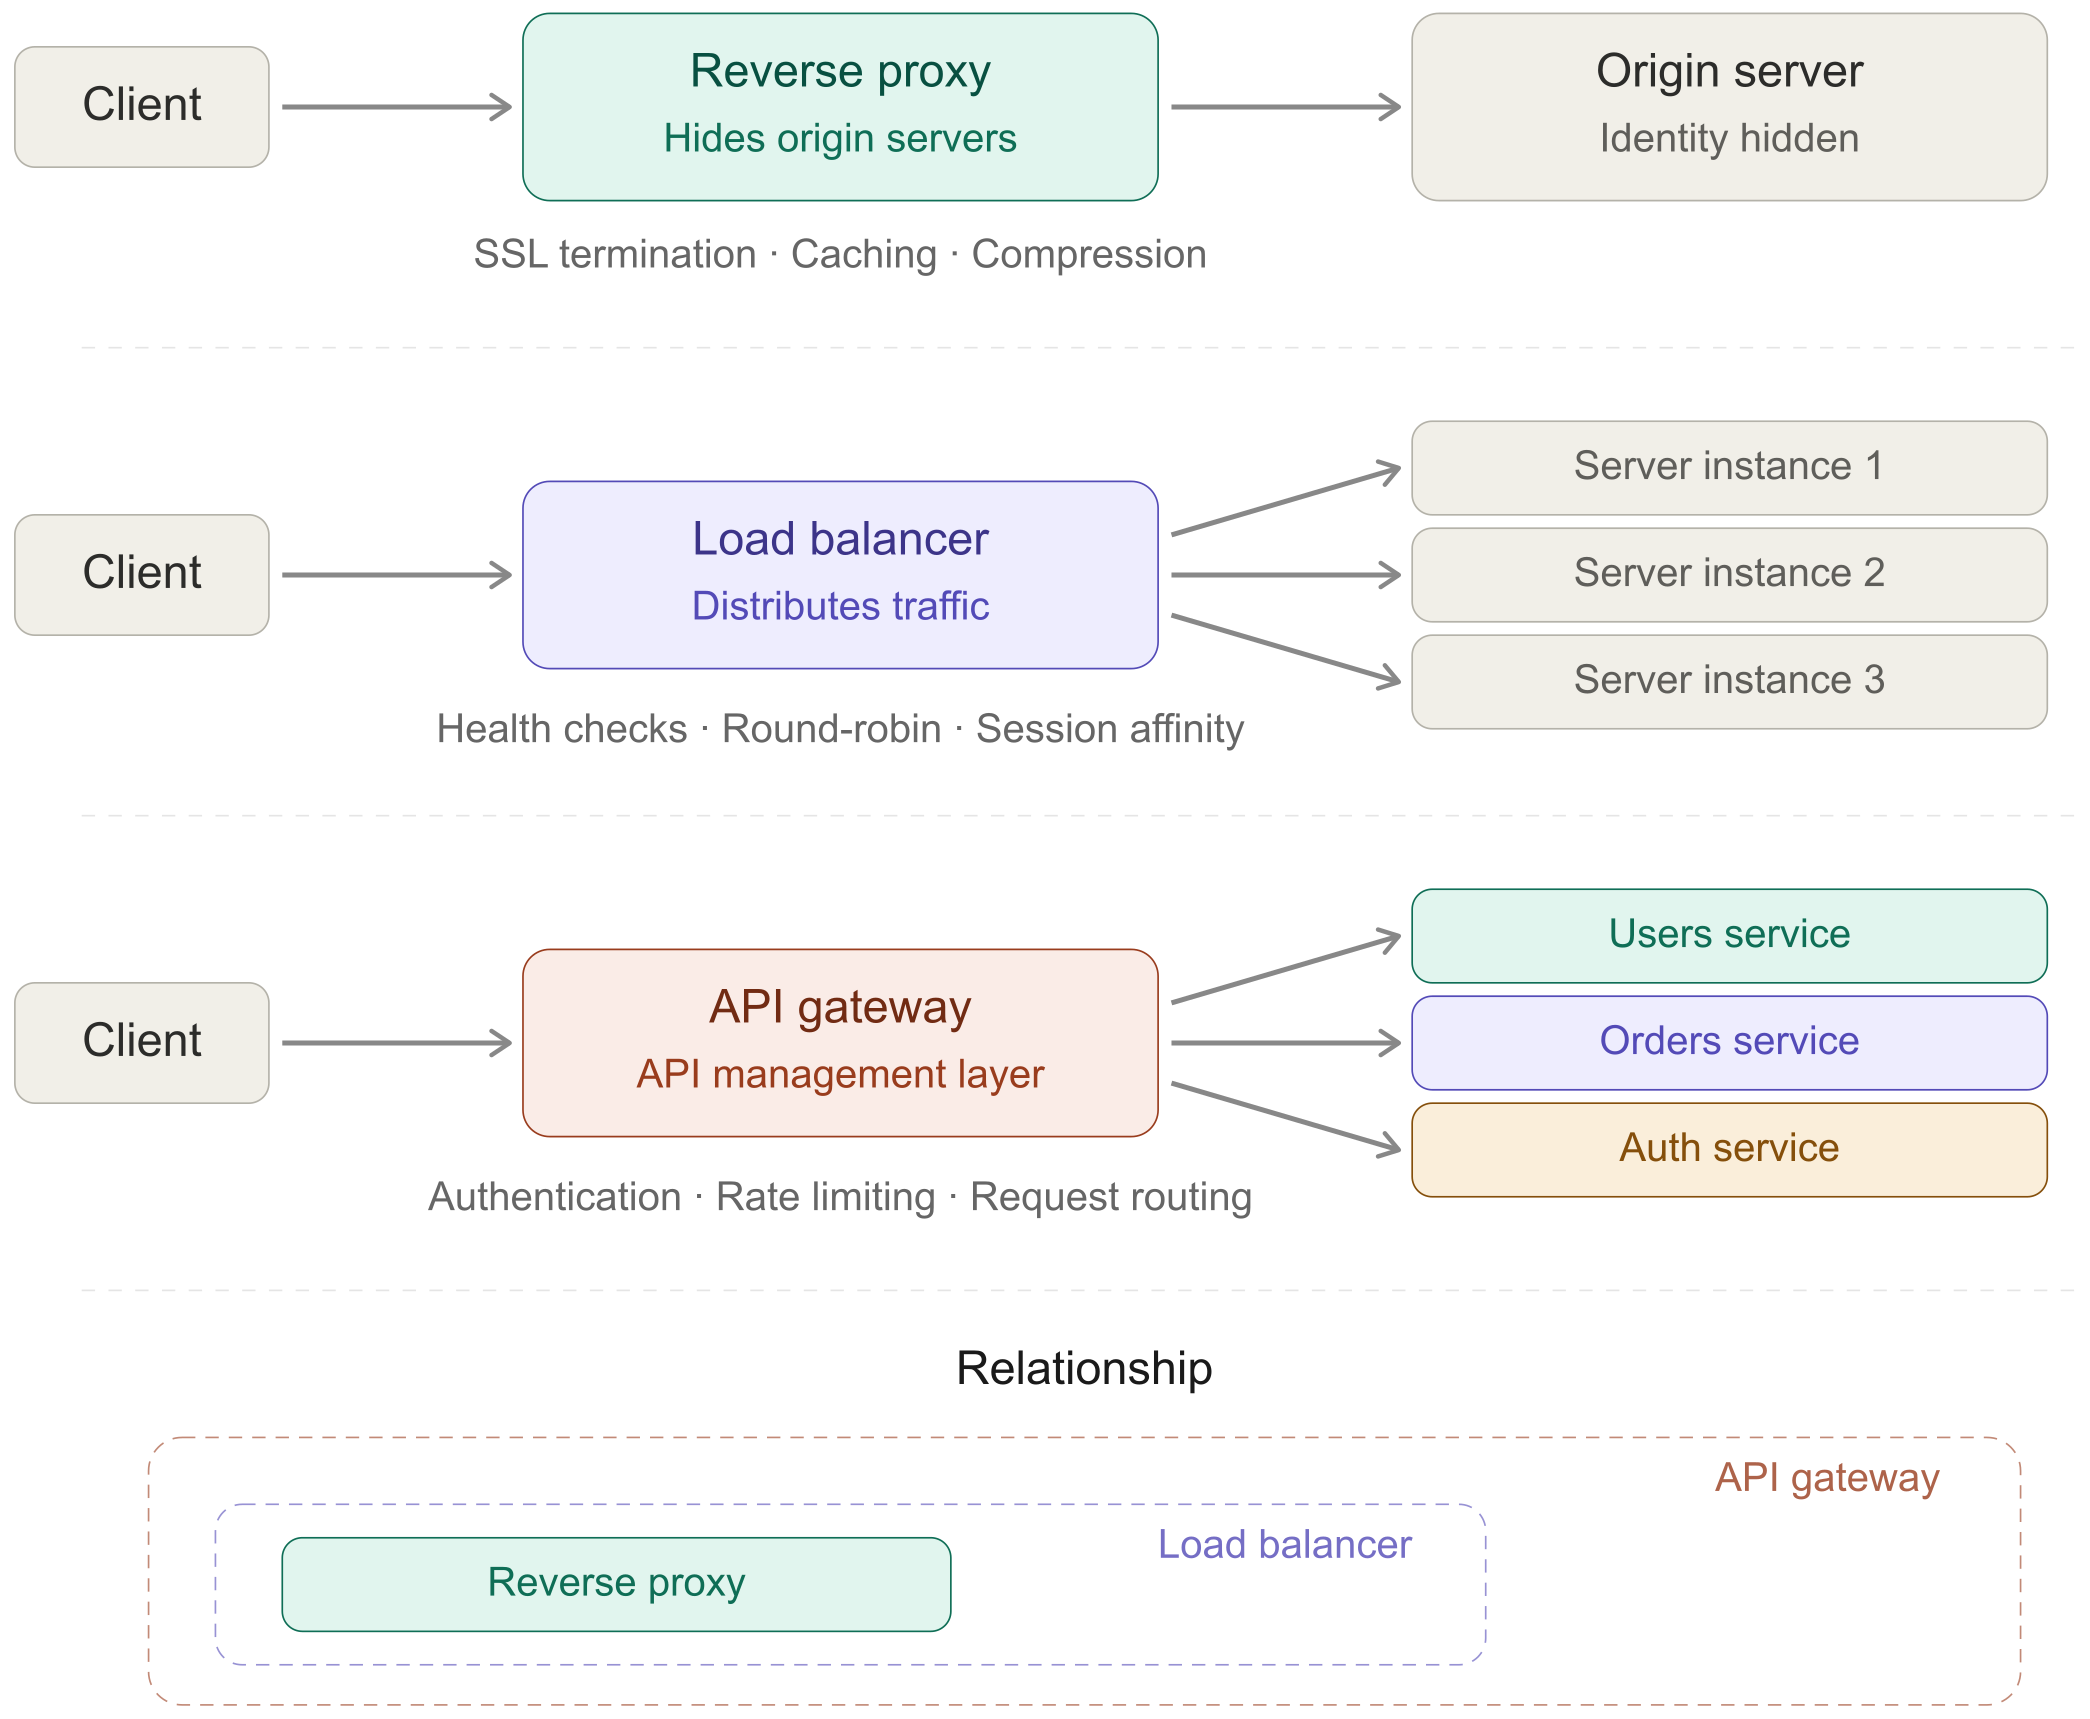

Однако даже с load-balancer'ом и остальным плюшками, которые нам может дать параллелизация, высоконагруженные приложения могут страдать от больших проблем. Представим себе ситуацию запроса к UniProt, попросим какую-то информацию для 10 белков.

In [3]:
def get_protein_names_sync(accessions):
  names = {}
  for acc in accessions:
    url = f"https://www.ebi.ac.uk/interpro/api/protein/uniprot/{acc}"
    try:
      resp = requests.get(url)
      data = resp.json()
      name = data.get('metadata', {}).get('name', 'Unknown')
      names[acc] = name
    except Exception:
      names[acc] = 'Error'
  return names

proteins = ['A0A009H0Q1', 'A0A006', 'A0A009H2L0', 'A0A009H0Z9', 'A0A009GYQ4', 'A0A009H2F4', 'A0A004', 'A0A009H2N6', 'A0A009H0Q1', 'A0A009']

In [4]:
%%time
sync_results = get_protein_names_sync(proteins * 10)

CPU times: user 757 ms, sys: 70 ms, total: 827 ms
Wall time: 34.8 s


Запрос 100 белков занял у нашего кода 35 секунд! При этом метрика CPU time в сумме даёт не более 1.5 секунд. На что тратилось время? На ожидание гуляния пакетов по интернету $-$ мы с вами обсуждали то, что в сетевых протоколах существуют причины задержки пакетов.

Есть ли способ "отпустить" ход процессора, пока мы ждём пакетов? Хочется просто запускать отдельные запросы и ждать, пока результаты вернутся к нам. Такой подход называется **асинхронным программированием**. Выглядит это примерно так:

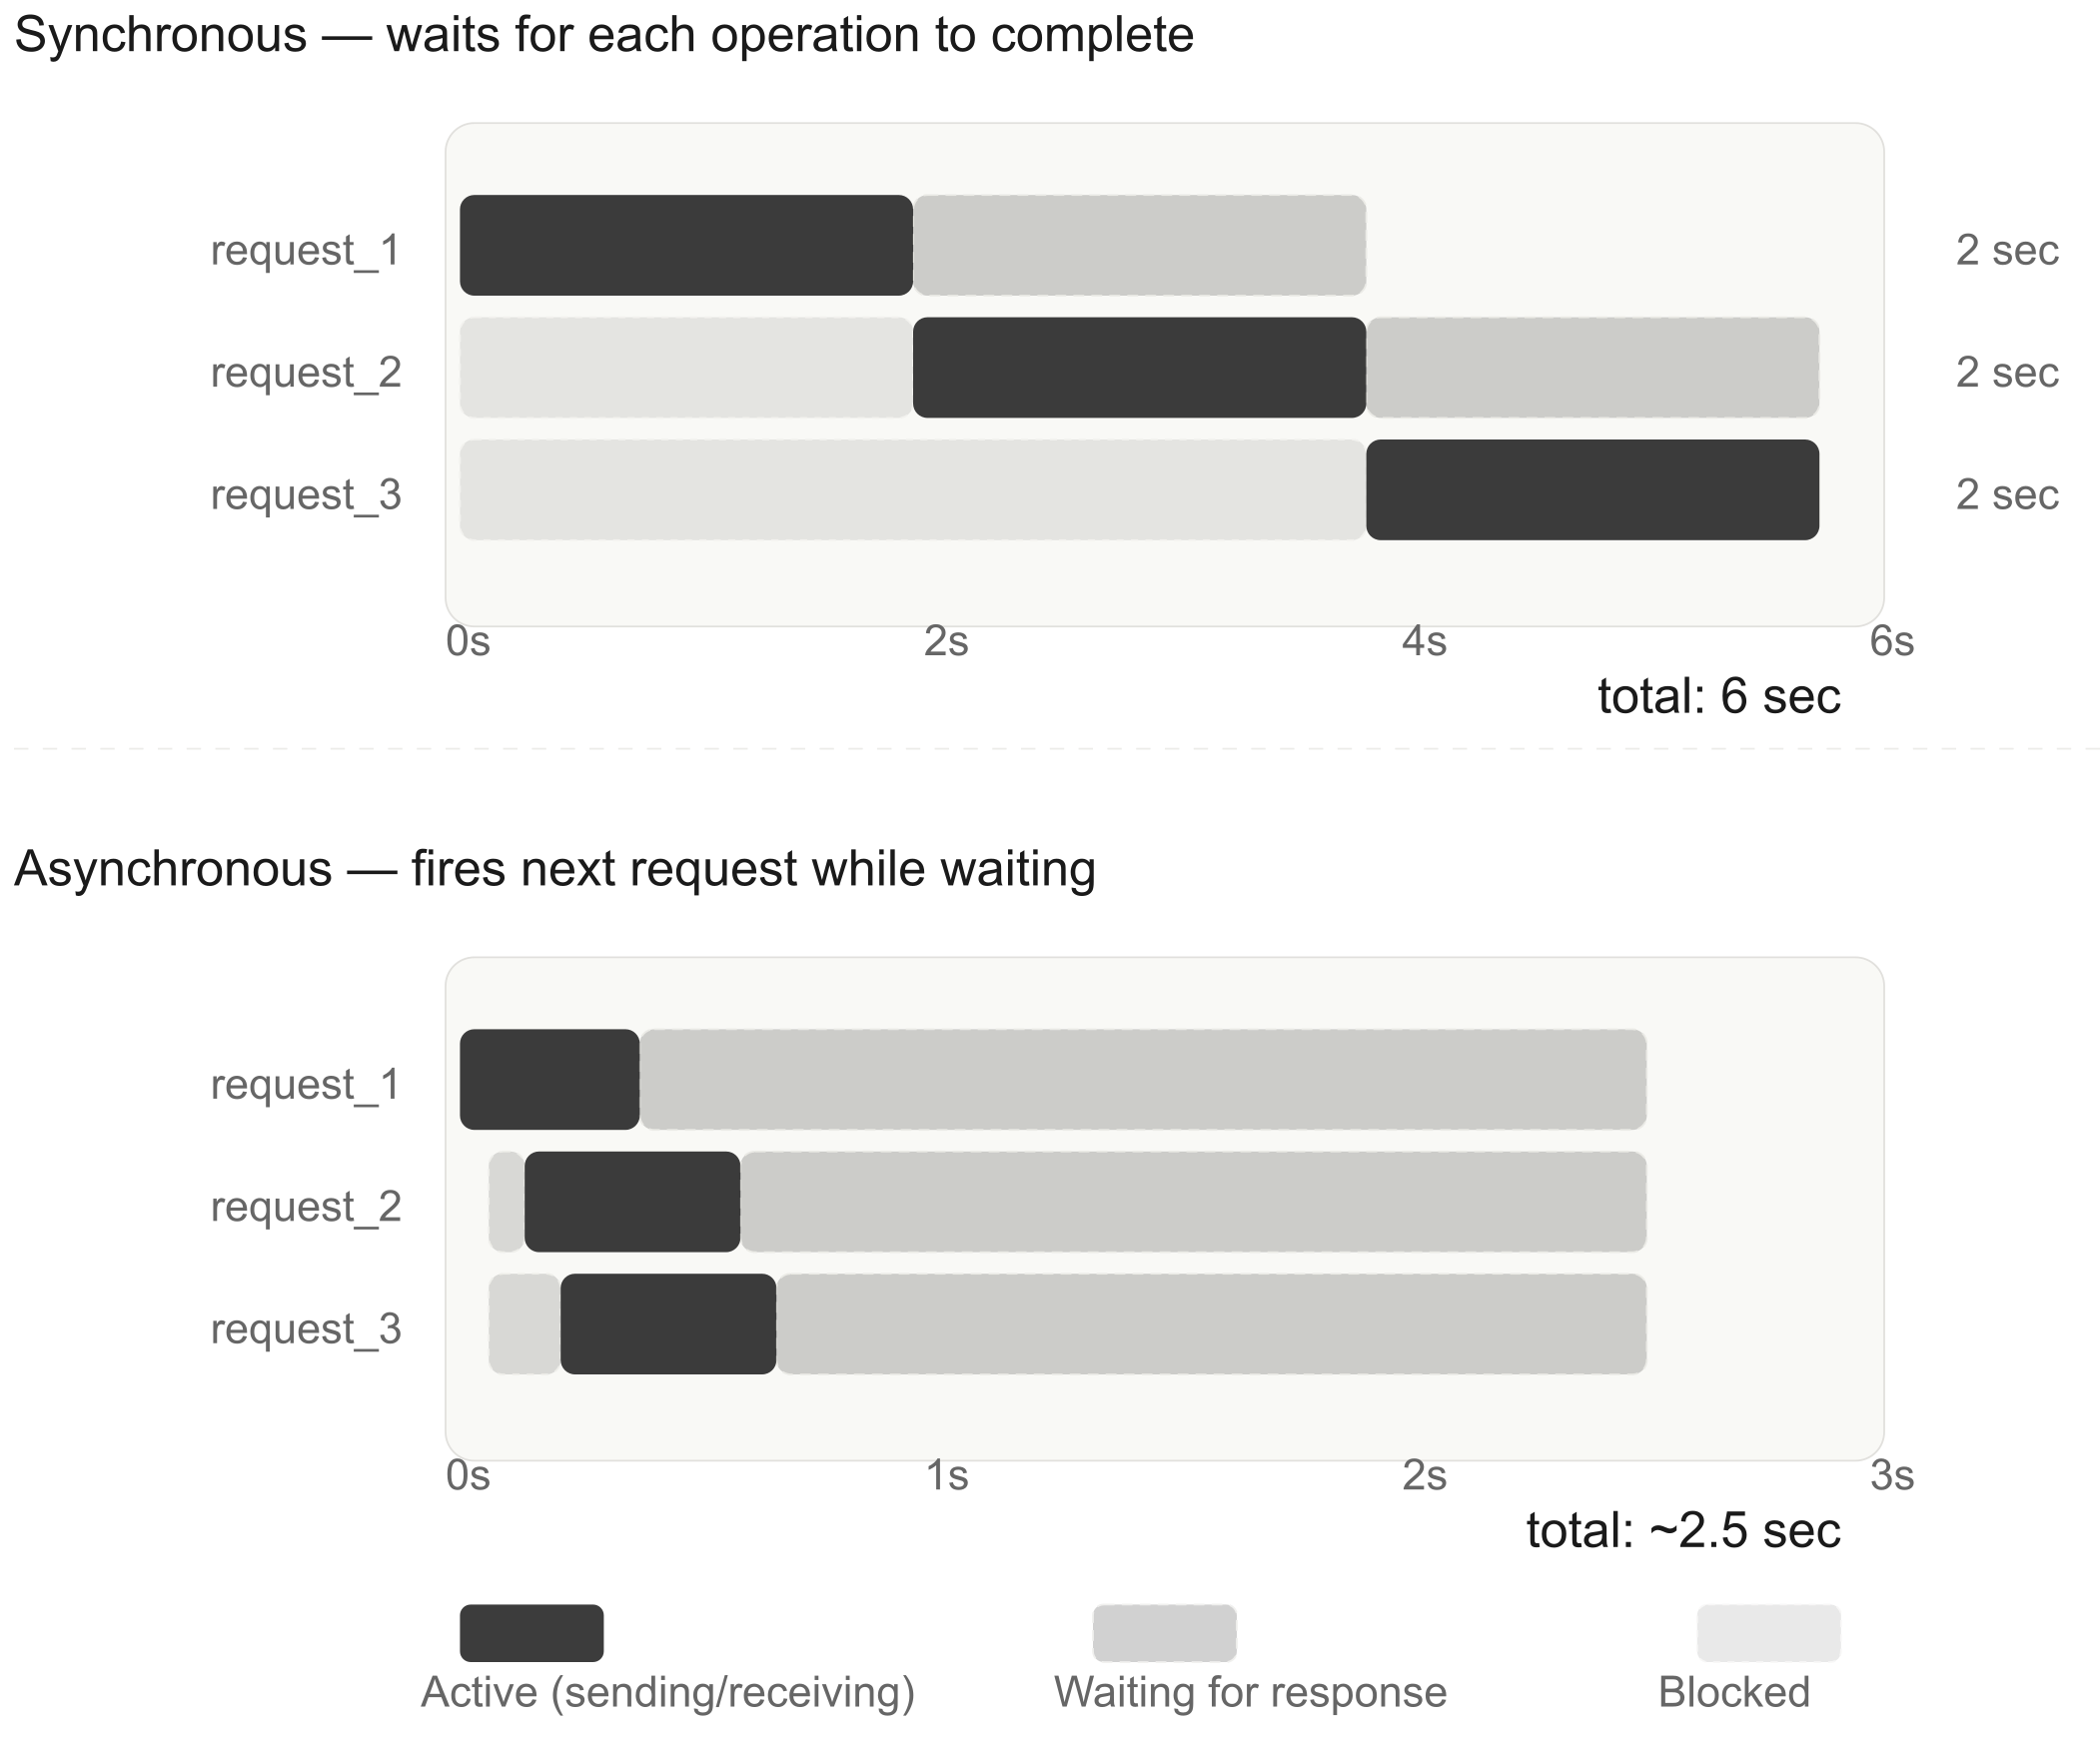


Ключевым понятием в асинхронном программировании является **event-loop** - один процесс, который менеджерит большое количество I/O-bound задач. Такие задачи называются корутинами (вспоминаем генераторы в Python) $-$ они умеют возвращать контроль обратно в event-loop. Точки, в которых происходит возврат контроля процессору, называются **`await`**-ами. В Python функции-корутины объявляются через `async def`.

In [5]:
# обычная функция выполняется сразу
def regular():
  return 42

# корутина возвращает объект, который нужно await'ить
async def coroutine():
  return 42

print(type(regular()))
print(type(coroutine()))

<class 'int'>
<class 'coroutine'>


/tmp/ipykernel_93651/1842089944.py:10: RuntimeWarning: coroutine 'coroutine' was never awaited
  print(type(coroutine()))


Детский пример: `asyncio.sleep` $-$ неблокирующая пауза, имитируем ответ от API. Пусть задержка ответа примерно 5 секунд. Ключевое слово `await` обычно пишется в моменте, где мы ожидаем задержку, не зависящую от нашего кода. Именно в этом моменте, когда CPU дойдёт до этой строки, контроль вернётся в event-loop.

Здесь же, мы можем в параллели запустить асинхронные запросы с помощью `asyncio.gather`. Обращаем внимание, что даже при том, что мы параллелим асинхронные запросы, мы всё равно должны их await-ить!

In [6]:
async def fetch_protein_data(protein_id, delay):
  await asyncio.sleep(delay)
  return {"id": protein_id, "length": 100 + len(protein_id) * 50}

async def fetch_all():
  tasks = [fetch_protein_data(pid, 5)
            for pid in ["P53_HUMAN", "BRCA1_HUMAN", "EGFR_HUMAN"]]
  return await asyncio.gather(*tasks)


t0 = time.perf_counter()
results_seq = []
for pid in ["P53_HUMAN", "BRCA1_HUMAN", "EGFR_HUMAN"]:
  # пример синхронного программирования в async-фреймфорке
  r = asyncio.run(fetch_protein_data(pid, 5))
  results_seq.append(r)
elapsed_seq = time.perf_counter() - t0

t0 = time.perf_counter()
results_par = asyncio.get_event_loop().run_until_complete(fetch_all())
elapsed_par = time.perf_counter() - t0

print(f"Последовательно: {elapsed_seq:.2f}")
print(f"Параллельно:     {elapsed_par:.2f}")

Последовательно: 15.02
Параллельно:     5.01


С помощью `asyncio.create_task` можно создать корутину-задачу, которую event-loop будет готов await-ить. При этом, `await` этой корутины будет запущен как только любая корутина будет `await`-лена. Если код и результат ниже вам понятен, то у вас получилось разобраться с тем, как работает event-loop.

Фактически, регистрация корутины в event-loop'е происходит через обвязку-объект типа `Task`. `gather` конвертирует все переданные ему корутины в таски и запускает `await` их всех.

In [7]:
async def counter_loop(x, n):
  for i in range(1, n + 1):
    print(f"Counter {x}: {i}")
    await asyncio.sleep(0.5)
  return f"Finished {x} in {n}"

async def main():
  slow_task = asyncio.create_task(counter_loop("Slow", 4))
  fast_coro = counter_loop("Fast", 2)

  print("Awaiting Fast")
  fast_val = await fast_coro
  print("Finished Fast")

  print("Awaiting Slow")
  slow_val = await slow_task
  print("Finished Slow")

asyncio.run(main())

Awaiting Fast
Counter Fast: 1
Counter Slow: 1
Counter Fast: 2
Counter Slow: 2
Finished Fast
Awaiting Slow
Counter Slow: 3
Counter Slow: 4
Finished Slow


Внешние API (Ensembl, NCBI, UniProt) имеют rate limits. Если мы запустим очень много запросов одновременно, то получим `429 Too Many Requests`. В `asyncio` существует механизм ограничения количества одновременно выполняющихся корутин. Он называется **семафор**, он задаётся с помощью отдельного объекта `asyncio.Semaphore`.

Для того, чтобы этот семафор работал, он должен существовать в нелокальной области видимости корутины. Использование семафора позволяет создать асинхронный контекст `async with Semaphore` (вместо применения `Semaphore.acquire()` и `Semaphore.release`).

In [8]:
sem = asyncio.Semaphore(3)

async def worker(i):
  async with sem:
    print(f"start {i}")
    await asyncio.sleep(1)
    print(f"end {i}")

async def main():
  tasks = [asyncio.create_task(worker(i)) for i in range(7)]
  await asyncio.gather(*tasks)

asyncio.run(main())

start 0
start 1
start 2
end 0
end 1
end 2
start 3
start 4
start 5
end 3
end 4
end 5
start 6
end 6


Кроме этого, есть механизм не ждать какую-то корутину: `asyncio.wait_for(..., timeout=N)`. У каждой запущенной задачи (Task) есть метод `Task.done()`, возвращающий булевское значение.

In [9]:
async def slow_request():
  await asyncio.sleep(10)
  return "done"

async def with_timeout():
  try:
    result = await asyncio.wait_for(slow_request(), timeout=2.0)
    return result
  except asyncio.TimeoutError:
    return "TIMEOUT: No response"

result = asyncio.run(with_timeout())
print(result)

TIMEOUT: No response


Раз теперь мы разобрались с `asyncio`, наверное, можно попробовать ещё раз написать код для взаимодействия с API, но теперь уже асинхронно. Пробуем и замеряем:

In [10]:
async def get_name(acc):
  url = f"https://www.ebi.ac.uk/interpro/api/protein/uniprot/{acc}"
  try:
    resp = requests.get(url)
    data = resp.json()
    return acc, data.get('metadata', {}).get('name', 'Unknown')
  except Exception:
    return acc, 'Error'

async def get_protein_names_async(accessions):
  tasks = [asyncio.create_task(get_name(acc)) for acc in accessions]
  results = await asyncio.gather(*tasks)
  return dict(results)

In [11]:
%%time
async_results = asyncio.run(get_protein_names_async(proteins * 10))

CPU times: user 715 ms, sys: 67.8 ms, total: 783 ms
Wall time: 34.3 s


Незадача. Почему не сработало? Время примерно то же. Всё потому что `requests` - синхронная библиотека. Для асинхронных целей умные люди придумали `aiohttp`.
| | `requests` | `aiohttp` |
|---|---|---|
| Сессия | `requests.Session()` | `aiohttp.ClientSession()` |
| Запрос | `r = session.get(url)` | `r = await session.get(url)` |
| Тело ответа | `r.json()` | `await r.json()` |

Важное отличие $-$ если в `requests` мы могли обойтись без контекста сессии (что мы и делали выше), то в `aiohttp` контекст сессии становится **обязательным**.

In [19]:
async def get_protein_names_async(accessions):
  async def fetch(session, acc):
    url = f"https://www.ebi.ac.uk/interpro/api/protein/uniprot/{acc}"
    try:
      async with session.get(url, timeout=10) as resp:
        data = await resp.json()
        return acc, data.get('metadata', {}).get('name', 'Unknown')
    except Exception:
      return acc, 'Error'

  async with aiohttp.ClientSession() as session:
    tasks = [fetch(session, acc) for acc in accessions]
    results = await asyncio.gather(*tasks)
  return dict(results)

In [20]:
%%time
async_results = asyncio.run(get_protein_names_async(proteins * 10))

CPU times: user 489 ms, sys: 64.8 ms, total: 554 ms
Wall time: 1.06 s


Ура! Получилось наконец забрать эффективность по времени выполнения. Важно понимать, что исходно Python не проектировался с рассчетом на асинхронную парадигму, поэтому API `asyncio` и `aiohttp` постоянно меняется и развивается до сих пор. Более подробное введение в асинронщину можно почитать [тут](https://jacobpadilla.com/articles/handling-asyncio-tasks). Ниже пример для разбора на дом с семафором, обращаемся с Ensembl API.

In [21]:
async def get_gene_info(session, sem, symbol):
  async with sem:
    url = f"https://rest.ensembl.org/xrefs/symbol/homo_sapiens/{symbol}"
    headers = {"Content-Type": "application/json"}
    try:
      async with session.get(url, headers=headers,
                              timeout=aiohttp.ClientTimeout(total=10)) as resp:
        if resp.status == 429:
          wait = int(resp.headers.get("Retry-After", 2))
          await asyncio.sleep(wait)
          return await get_gene_info(session, sem, symbol)
        if resp.status != 200:
          return {"symbol": symbol, "error": f"HTTP {resp.status}"}
        data = await resp.json()
        gene_entry = next((x for x in data if x.get("type") == "gene"), None)
        if not gene_entry:
          return {"symbol": symbol, "error": "no xref"}
        return {"symbol": symbol, "ensembl_id": gene_entry["id"]}
    except asyncio.TimeoutError:
      return {"symbol": symbol, "error": "timeout"}

async def lookup_genes(symbols, max_concurrent=5):
  sem = asyncio.Semaphore(max_concurrent)
  async with aiohttp.ClientSession() as session:
    tasks = [get_gene_info(session, sem, s) for s in symbols]
    return await asyncio.gather(*tasks)

genes = ["TP53", "BRCA1", "EGFR", "BRCA2", "BRAF",
         "PIK3CA", "KRAS", "PTEN", "RB1", "NOTAFAKEGENE"]

t0 = time.perf_counter()
results = asyncio.get_event_loop().run_until_complete(lookup_genes(genes))
elapsed = time.perf_counter() - t0

for r in results:
  if "error" in r:
    print(f"- {r['symbol']}: {r['error']}")
  else:
    print(f"+ {r['symbol']}: {r['ensembl_id']}")
print(f"\n{len(genes)} genes parsed in {elapsed:.2f}s using (sem=5)")

+ TP53: ENSG00000141510
+ BRCA1: ENSG00000012048
+ EGFR: ENSG00000146648
+ BRCA2: ENSG00000139618
+ BRAF: ENSG00000157764
+ PIK3CA: ENSG00000121879
+ KRAS: ENSG00000133703
+ PTEN: ENSG00000171862
+ RB1: ENSG00000139687
- NOTAFAKEGENE: no xref

10 genes parsed in 0.52s using (sem=5)


Библиотека `python-telegram-bot` полностью асинхронная. Все операции (отправка сообщений, получение обновлений) являются корутинами.

- Скрипт обработки данных работает часами = уведомление о завершении / ошибке
- Пайплайн из нескольких этапов = прогресс в Telegram
- Мониторинг серверов и очередей задач

Настройка производится как в презентации ко второй лекции. **ВАЖНО:** не храните и не вставляйте в коммит код, где хранится ваш секрет. API-ключей на гитхабе полно, не добавляйте новые. Хорошим тоном является хранение API-ключей в словаре переменных вашего компьютера (environment variables), из которых с помощью `os` вытаскиваются их значения.

Ваша задача в ДЗ $-$ разобраться с API функций библиотеки telebot, написать своего бота (см. [ДЗ](https://github.com/dkhlebn/FBB-orchestration/blob/main/homeworks/FBBOrch.HW2.Scraping.Crawling.API.FastAPI.pdf)).

In [ ]:
BOT_TOKEN = os.environ.get("TGBOT_TOKEN")
TG_AVAILABLE = BOT_TOKEN is not None

In [ ]:
async def get_my_chat_id(token, username):
    bot = Bot(token=token)
    updates = await bot.get_updates()
    for update in updates:
        user = update.effective_user
        chat = update.effective_chat
        if user and chat and user.username == username:
            return chat.id
    return None

async def send_notification(token, chat_id, text, parse_mode="Markdown"):
    bot = Bot(token=token)
    await bot.send_message(chat_id=chat_id, text=text, parse_mode=parse_mode)

chat_id = asyncio.get_event_loop().run_until_complete(
    get_my_chat_id(BOT_TOKEN, "your_username")
    )
asyncio.run(
    send_notification(BOT_TOKEN, chat_id, "Тестовое сообщение от семинара!")
    )

Последнее, что нужно обсудить в контексте всего сказанного выше, $-$ интерфейс сервера и как его писать. На самом деле, то что мы обсуждали ранее (фреймворк fastAPI) уже предоставляет асинхронный сервер из коробки такой, что его API асинхронно взаимодействует с запросами, которые на него приходят. Однако полезно понимать, как такое взаимодействие можно написать руками.

На лекции мы обсуждали сокеты протоколов TCP и UDP. В слайдах лекции показано, как на низком уровне проектируются сокеты TCP, здесь рассмотрим UDP. Вспомним различие между протоколами:


| | TCP | UDP |
|---|---|---|
| Соединение | Есть (handshake) | Нет |
| Гарантия доставки | Да | Нет |
| Порядок пакетов | Гарантирован | Не гарантирован |
| Overhead | Больше | Меньше |
| Применение | HTTP, SSH, FTP | DNS, видеостриминг, игры |

В **UDP** датаграмма может потеряться, прийти дважды или в другом порядке. Если нам нужна надёжность — реализуем её *сами* поверх UDP (таймауты, ретрансмиссии, нумерация пакетов). Пользоваться будем стандартной библиотекой `socket`.

Простейшая задача: echo-сервер, повторяющий написанное клиентом.

In [59]:
import socket
import asyncio
import threading
import time
import random

Для UDP сервера нам требуется с помощью `socket.socket` создать сокет UDP и привязать его к порту. Передаём внутрь сокета информацию о том, что это сокет интернета (`socket.AF_INET`) и он относится к UDP (`socket.SOCK_DGRAM`). Затем привязываем сокет к порту в ос с помощью `.bind()`, устанавливаем таймаут по запросам.

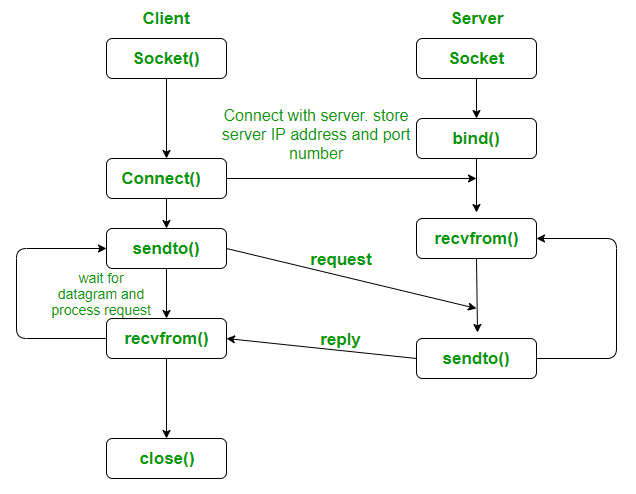

С точки зрения сервера мы должны принимать с помощью `.recvfrom` и отправлять с помощью `.sendto`. Метод сокета `recvfrom` принимает размер буфера в байтах, `sendto` также требует адреса получения данных.

In [13]:
def udp_echo_server(host, port, stop_event):
  sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
  sock.bind((host, port))
  sock.settimeout(0.5)
  while not stop_event.is_set():
    try:
      data, addr = sock.recvfrom(1024)
      message = data.decode()
      sock.sendto(message.upper().encode(), addr)
    except socket.timeout:
      continue
    sock.close()

Со стороны клиентского приложения мы также создаём сокет и задаём тайм-аут, только данные сначала отправляем, а потом получаем. Обратите внимание, что в отличие от TCP-соединения, UDP-сокет не персистентный и закрывается после передачи сообщения.

In [12]:
def udp_client_send(host, port, message, timeout=2.0):
  sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
  sock.settimeout(timeout)
  try:
    sock.sendto(message.encode(), (host, port))
    data, _ = sock.recvfrom(1024)
    return data.decode()
  except socket.timeout:
    return "TIMEOUT"
  finally:
    sock.close()

Запустим всё вместе:

In [4]:
stop = threading.Event()
server_thread = threading.Thread(target=udp_echo_server, args=("127.0.0.1", 9999, stop))
server_thread.start()
time.sleep(0.2)


for msg in ["atggccattgtaatg", "meepqsdpsveppl", "hello udp"]:
  response = udp_client_send("127.0.0.1", 9999, msg)
  print(f"Data sent: {msg};\nData recv: {response};")


stop.set()
server_thread.join()

Data sent: atggccattgtaatg;
Data recv: ATGGCCATTGTAATG;
Data sent: meepqsdpsveppl;
Data recv: MEEPQSDPSVEPPL;
Data sent: hello udp;
Data recv: HELLO UDP;


Однако, как мы знаем из лекции, не все пакеты из будут получены $-$ UDP не гарантирует доставку. Что делать, если сервер не ответил? Стандартный паттерн: **retry с таймаутом**.

In [5]:
def udp_send_with_retry(host, port, message, timeout=1.0, max_retries=3):
  sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
  sock.settimeout(timeout)

  for attempt in range(1, max_retries + 1):
    try:
      sock.sendto(message.encode(), (host, port))
      data, _ = sock.recvfrom(1024)
      sock.close()
      return data.decode(), attempt
    except socket.timeout:
      if attempt < max_retries:
        continue
  sock.close()
  return None, max_retries

Запустим на сервере с неправильным портом.

In [8]:
stop = threading.Event()
server_thread = threading.Thread(target=udp_echo_server, args=("127.0.0.1", 9999, stop))
server_thread.start()
time.sleep(0.2)

t0 = time.perf_counter()
response, attempts = udp_send_with_retry("127.0.0.1", 19886, "HELO", timeout=0.5, max_retries=10)
elapsed = time.perf_counter() - t0

if response is None:
  print(f"Сервер не ответил за {attempts} попыток ({elapsed:.1f}с)")
else:
  print(f"Ответ: {response} (попытка {attempts})")

stop.set()
server_thread.join()

Сервер не ответил за 10 попыток (5.0с)


А теперь симулируем реальность: пусть сервер с вероятность 0.8 отбросит пакет UDP.

In [22]:
def udp_echo_server_rng(host, port, stop_event):
  sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
  sock.bind((host, port))
  sock.settimeout(0.5)
  while not stop_event.is_set():
    try:
      data, addr = sock.recvfrom(1024)
      message = data.decode()
      if random.random() > 0.8:
        sock.sendto(message.upper().encode(), addr)
    except socket.timeout:
      continue
  sock.close()

In [23]:
stop = threading.Event()
server_thread = threading.Thread(target=udp_echo_server_rng, args=("127.0.0.1", 9999, stop))
server_thread.start()
time.sleep(0.2)

t0 = time.perf_counter()
response, attempts = udp_send_with_retry("127.0.0.1", 9999, "HELO", timeout=0.5, max_retries=10)
elapsed = time.perf_counter() - t0

if response is None:
  print(f"Сервер не ответил за {attempts} попыток ({elapsed:.1f}с)")
else:
  print(f"Ответ: {response} (попытка {attempts})")

stop.set()
server_thread.join()

Ответ: HELO (попытка 4)


Отдельное дело $-$ хранить состояния, то есть делать из stateless протокола stateful. Для этого нам потребуется хранить информацию о клиенте внутри программы сервера. Обычно в случае реализации такой обвязки к серверу, взаимодействующему с пакетами, подключают клиентскую БД, к которой сервер может обращаться, но в учебных условиях мы можем обойтись словарём.

In [52]:
def generate_secret(address):
  from hashlib import sha256
  return sha256(address.encode('utf-8')).hexdigest()


def udp_echo_server_stateful(host, port, stop_event):
  sessions = {}
  sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
  sock.bind((host, port))
  sock.settimeout(0.5)
  while not stop_event.is_set():
    try:
      data, addr = sock.recvfrom(1024)
      if addr[0] not in sessions:
        sessions[addr[0]] = {"state": "NEW", "secret": generate_secret(addr[0]), "count": 1}
      else:
        sessions[addr[0]]["count"] += 1
        sessions[addr[0]]["state"] = "IN-PROGRESS"
      session = sessions[addr[0]]
      message = data.decode()
      if session["state"] == "NEW":
        sock.sendto(f"Response to the first interaction. Secret: {session["secret"]}".encode(), addr)
      elif session["state"] == "IN-PROGRESS":
        sock.sendto(f"Session in Progress, #Interactions: {session["count"]}".encode(), addr)
    except socket.timeout:
      continue
  sock.close()

In [54]:
stop = threading.Event()
server_thread = threading.Thread(target=udp_echo_server_stateful, args=("127.0.0.1", 9999, stop))
server_thread.start()
time.sleep(0.2)


for msg in ["atggccattgtaatg", "meepqsdpsveppl", "hello udp"]:
  response = udp_client_send("127.0.0.1", 9999, msg)
  print(f"Data sent: {msg};\nData recv: {response};")
  print('-' * 50)


stop.set()
server_thread.join()

Data sent: atggccattgtaatg;
Data recv: Response to the first interaction. Secret: 12ca17b49af2289436f303e0166030a21e525d266e209267433801a8fd4071a0;
--------------------------------------------------
Data sent: meepqsdpsveppl;
Data recv: Session in Progress, #Interactions: 2;
--------------------------------------------------
Data sent: hello udp;
Data recv: Session in Progress, #Interactions: 3;
--------------------------------------------------


Однако вот незадача: `recvfrom` блокирует поток и не является асинхронным. То есть, если сервер ждёт пакета от клиента A, то он не сможет обслужить клиента B:

```
Клиент A:  HELO ──────────────────── RESPONSE ─────────────────────────
Клиент B:  ──────── HELO ────────── (ждёт, пока сервер освободится) ...
Сервер:    [recv A] [send A] [recv... блокировка .....................]
```

Библиотека `asyncio` спасает вновь: в неё есть возможность создавать асинхронные сокеты.

`asyncio` предоставляет встроенный механизм для работы с UDP через класс `DatagramProtocol`. Вместо блокирующего `recvfrom` event loop *сам* вызывает ваш callback `datagram_received`, когда приходит пакет.

```
                    ┌─────────────────────────────────┐
                    │       Event Loop                │
                    │                                 │
  UDP пакет ──────> │  datagram_received(data, addr)  │
                    │       │                         │
                    │       V                         │
                    │  обработка + sendto()           │
                    │       │                         │
  UDP ответ <────── │  transport.sendto(resp, addr)   │
                    └─────────────────────────────────┘
```

`DatagramProtocol` $-$ родительский класс, от которого можно наследоваться, чтобы `asyncio` выполнял оркестрацию event-loop'а сервера за вас. Для этого, потребуется реализовать следующие методы `DatagramProtocol` (первые два обязательны):
- **`connection_made(transport)`** — вызывается при запуске, сохраняем `transport`;
- **`datagram_received(data, addr)`** — вызывается при получении каждой датаграммы;
- `error_received(exc)` — ошибка при отправке;
- `connection_lost(exc)` — закрытие.

`transport.sendto(data, addr)` — отправка ответа. `transport` = обёртка над UDP-сокетом, через которую можно отправлять датаграммы, закрывать соединение и получать информацию о сокете, методы у неё те же, что у объектов-сокетов из базовой библиотеки.

Например, вот так будет выглядеть код для нашего UDP-echo-сервера:

In [60]:
class EchoServerProtocol(asyncio.DatagramProtocol):
  def connection_made(self, transport):
    self.transport = transport

  def datagram_received(self, data, addr):
    message = data.decode()
    response = message.upper()
    self.transport.sendto(response.encode(), addr)

Так мы отправляем сервер в event-loop `aysncio` $-$ минимум отличий от того, что делали раньше:

In [61]:
async def run_server():
  loop = asyncio.get_running_loop()

  transport, protocol = await loop.create_datagram_endpoint(
      EchoServerProtocol,
      local_addr=("127.0.0.1", 9998),
  )

  try:
    await asyncio.sleep(30)
  finally:
    transport.close()

def start_server():
  asyncio.run(run_server())

Код для клиента (клиенту *можно* быть синхронным):

In [67]:
def run_client():
  s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
  s.settimeout(2)
  for msg in ["atgcgatcg", "protein query", "blast result"]:
    s.sendto(msg.encode(), ("127.0.0.1", 9998))
    resp, _ = s.recvfrom(1024)
    print(f"{msg} \t<--->\t {resp.decode()}")
  s.close()

Запустим клиент и сервер в разных event-loop'ах с помощью `multithreading`:

In [68]:
from multiprocessing import Process
import time

server_proc = Process(target=start_server)
server_proc.start()

time.sleep(1)

run_client()

# обвязка для завершения работы сервера
server_proc.terminate()
server_proc.join()

atgcgatcg 	<--->	 ATGCGATCG
protein query 	<--->	 PROTEIN QUERY
blast result 	<--->	 BLAST RESULT


Дополнительно, чтобы память сервера не забивалась, часто требуется реализовать логику отбрасывания соединений, которые давно ничего не присылали:

In [ ]:
class Protocol(asyncio.DatagramProtocol):

  def __init__(self, timeout=30):
    self.sessions = {}
    self.timeout = timeout

  def connection_made(self, transport):
    self.transport = transport
    asyncio.create_task(self.cleanup_task())

  def datagram_received(self, data, addr):
    self.sessions[addr] = time.time()

  async def cleanup_task(self):
    while True:
      await asyncio.sleep(5)
      now = time.time()
      stale = [
        addr for addr, last in self.sessions.items()
        if (now - last) > self.timeout
      ]
      for addr in stale:
        del self.sessions[addr]

Итог: как устроен наш сервер

```
┌─────────────────────────────────────────────────────┐
│                    Event Loop                       │
│                                                     │
│  ┌─────────────────────┐   ┌──────────────────────┐ │
│  │  DatagramProtocol   │   │ periodic_cleanup()   │ │
│  │                     │   │ (фоновая задача)     │ │
│  │  datagram_received()│   │                      │ │
│  │    │                │   │  await sleep(10)     │ │
│  │    ├─ HELO = новая  │   │  protocol.cleanup()  │ │
│  │    │   сессия       │   │  await sleep(10)     │ │
│  │    ├─ ...           │   │  ...                 │ │
│  │    │                │   │                      │ │
│  │    └─ sendto()      │   └──────────────────────┘ │
│  │                     │                            │
│  │  sessions = {       │    Всё работает в одном    │
│  │    addr1: Session,  │    потоке, без блокировок! │
│  │    addr2: Session,  │                            │
│  │    ...              │                            │
│  │  }                  │                            │
│  └─────────────────────┘                            │
└─────────────────────────────────────────────────────┘
```

Ключевые преимущества:
- Один поток, нет проблем с синхронизацией;
- `datagram_received` никогда не блокируется: event-loop вызывает его, когда пакет уже пришёл;
- Фоновые задачи (`cleanup`, `timeout tracking`) работают параллельно через `create_task`;
- Масштабируется на тысячи одновременных клиентов.

Такая логика реализуется backend-инженерами, в случае проектировки API на известных фреймворках она работает из коробки (например, в FastAPI или Flask/Django).